# MP-PSRP Quickstart

One notebook for the full workflow:
1. build one shared synthetic instance through `mppsrp_nir` and the CP-SAT data generator;
2. train `PPO`, `PPO-Lagrangian`, and `D3PO` on that exact instance;
3. compare `untrained policy` vs `trained policy`;
4. compare the trained RL policies against `CP-SAT`.

Here `untrained policy` means a rollout of the randomly initialized network before training.
`trained policy` means a rollout of the same network after optimization on the same instance.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
        


In [2]:
import importlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from omegaconf import OmegaConf

import src.train.notebook as notebook_utils
import src.benchmarks.cpsat as cpsat_utils

notebook_utils = importlib.reload(notebook_utils)
cpsat_utils = importlib.reload(cpsat_utils)

build_components_from_instance = notebook_utils.build_components_from_instance
comparison_config_frame = notebook_utils.comparison_config_frame
comparison_summary_frame = notebook_utils.comparison_summary_frame
cpsat_comparison_frame = notebook_utils.cpsat_comparison_frame
daily_route_frame = notebook_utils.daily_route_frame
episode_kpis = notebook_utils.episode_kpis
load_config = notebook_utils.load_config
plot_algorithm_comparison = notebook_utils.plot_algorithm_comparison
plot_algorithm_summary_dashboard = notebook_utils.plot_algorithm_summary_dashboard
plot_cpsat_comparison = notebook_utils.plot_cpsat_comparison
plot_daily_delivered = notebook_utils.plot_daily_delivered
plot_instance_map = notebook_utils.plot_instance_map
plot_inventory_dynamics = notebook_utils.plot_inventory_dynamics
plot_route_map = notebook_utils.plot_route_map
run_algorithm_suite = notebook_utils.run_algorithm_suite
station_summary_frame = notebook_utils.station_summary_frame
vehicle_summary_frame = notebook_utils.vehicle_summary_frame

build_cpsat_bundle = cpsat_utils.build_cpsat_bundle
build_euclidean_weight_matrix = cpsat_utils.build_euclidean_weight_matrix
compare_policy_to_cpsat = cpsat_utils.compare_policy_to_cpsat
cpsat_data_model_to_instance = cpsat_utils.cpsat_data_model_to_instance

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 3)
        


## 1. Experiment knobs

`benchmark` is a longer local run than `smoke`, while `full` is intended for heavier experiments.
`TRACKED_PRODUCT` controls the inventory-dynamics plot:
`0` or `1` for one product, or `None` for the aggregate station fill ratio.


In [3]:
EXPERIMENT_PRESET = "benchmark"     # smoke | benchmark | full
ENV_NAME = "small"                  # small | medium | real_case
ALGORITHMS = ["ppo", "ppo_lagrangian", "d3po"]
TRACKED_PRODUCT = 0                  # None -> aggregate fill ratio over all products
DETERMINISTIC_EVAL = True
BASE_OVERRIDES = []

POINTS = np.array(
    [
        [0.50, 0.50],
        [0.14, 0.18],
        [0.82, 0.16],
        [0.88, 0.74],
        [0.30, 0.86],
        [0.12, 0.62],
    ],
    dtype=np.float64,
)

BUILDER_CONFIG = {
    "distance_multiplier": 1,
    "travel_time_multiplier": 3600,
    "planning_horizon": 4,
    "safety_level": 0.10,
    "max_level": 0.95,
    "initial_inventory_level": 0.55,
    "tank_capacity": 100,
    "depot_service_time": 900,
    "station_service_time": 600,
    "demand": 10,
    "products_count": 2,
    "k_vehicles": 2,
    # simplified setup: one fixed compartment per product
    "compartments": [[40, 40]],
    "mean_vehicle_speed": 60,
    "vehicle_time_windows": [[9 * 3600, 18 * 3600]],
    "noise_initial_inventory": 0.0,
    "noise_tank_capacity": 0.0,
    "noise_compartments": 0.0,
    "noise_demand": 0.15,
    "noise_vehicle_time_windows": 0.0,
    "noise_restrictions": 0.0,
    "random_seed": 45,
}

CP_SAT_SOLVE_CONFIG = {
    "max_trips_per_day": 2,
    "time_limit_milliseconds": 10_000,
    "verbose": False,
}
        


## 2. Build one shared instance through the CP-SAT generator

Below we create one shared synthetic instance for both RL and CP-SAT.
This keeps the comparison fair: same coordinates, capacities, demand, vehicles, and planning horizon.


In [4]:
base_cfg = load_config([f"env={ENV_NAME}", f"experiment={EXPERIMENT_PRESET}", *BASE_OVERRIDES])
algorithm_labels = list(ALGORITHMS or base_cfg.experiment.comparison_algorithms)
configs = {
    label: load_config([f"env={ENV_NAME}", f"experiment={EXPERIMENT_PRESET}", f"algo={label}", *BASE_OVERRIDES])
    for label in algorithm_labels
}

display(comparison_config_frame(configs))

weight_matrix = build_euclidean_weight_matrix(POINTS, distance_scale=100.0)
bundle = build_cpsat_bundle(
    weight_matrix,
    BUILDER_CONFIG,
    solve=True,
    solve_config=CP_SAT_SOLVE_CONFIG,
)
instance = cpsat_data_model_to_instance(
    bundle["data_model"],
    max_steps=int(base_cfg.env.max_steps),
)

reference_cfg = configs[algorithm_labels[0]]
reference_env, _, _, _ = build_components_from_instance(reference_cfg, instance)
reference_obs, reference_info = reference_env.reset()

print("CP-SAT solution found:", bundle["solution_found"])
display(pd.DataFrame([bundle.get("kpis") or {}], index=["cpsat"]))
        


,env,algo,total_iterations,rollout_length,eval_interval,eval_episodes,learning_rate,clip_eps,minibatch_size
run,,,,,,,,,
ppo,small,ppo,100,64,5,6,3.000e-04,0.2,128
ppo_lagrangian,small,ppo_lagrangian,100,64,5,6,3.000e-04,0.2,128
d3po,small,d3po,100,64,5,6,3.000e-04,0.2,128


CP-SAT solution found: True


,total_travel_distance,total_travel_time,average_stock_levels,average_stock_levels_percent,dry_runs,average_vehicle_utilization,average_stops_per_trip
cpsat,0,0,"[231, 180, 131, 74]",33.342,0,0.0,0.0


## 3. Shared instance preview

Only the useful context stays here: station table, vehicle table, and the instance map.
No mask plot, no fill-ratio heatmap, and no available-quantity plot.


,station_id,x,y,station_class,days_since_last_delivery,valid_vehicles,mean_fill_ratio,min_days_until_stockout
0,5,1.000,0.372,0,0,2,0.579,4.286
1,2,0.000,0.907,0,0,2,0.579,4.390
2,4,0.796,0.000,0,0,2,0.579,4.390
3,1,0.901,1.000,0,0,2,0.579,4.500
4,3,0.014,0.071,0,0,2,0.579,4.737


,vehicle_id,current_node,time_in_shift,shift_remaining,trip_count,is_actionable,valid_nodes,loaded_volume,total_capacity
0,0,0,0.0,32400.0,0,True,6,80.0,80.0
1,1,0,0.0,32400.0,0,True,6,80.0,80.0


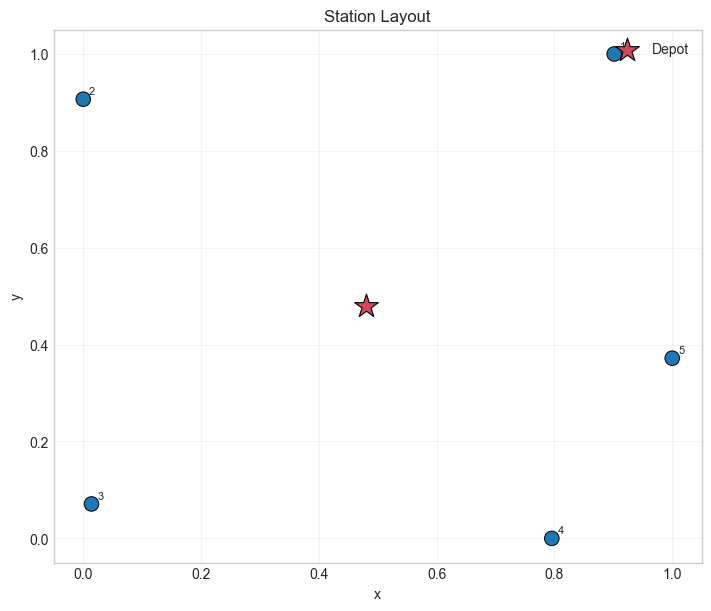

In [5]:
display(station_summary_frame(reference_env, reference_obs))
display(vehicle_summary_frame(reference_env, reference_obs))

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
plot_instance_map(reference_env, ax=ax)
plt.show()
        


## 4. Train the RL algorithms on this exact instance

`comparison` below does not mean "before vs after CP-SAT".
It means `untrained policy vs trained policy` on the same shared instance,
so we can see whether the network actually learned something useful.


In [ ]:
suite = run_algorithm_suite(
    configs,
    instance=instance,
    deterministic_eval=DETERMINISTIC_EVAL,
)
results = suite["results"]
summary_frame = comparison_summary_frame(results)

summary_columns = [
    "algo_name",
    "untrained_distance",
    "trained_distance",
    "distance_improvement_pct",
    "untrained_stockout",
    "trained_stockout",
    "stockout_improvement_pct",
    "eval_distance",
    "eval_stockout",
]
available_summary_columns = [col for col in summary_columns if col in summary_frame.columns]
display(summary_frame[available_summary_columns].sort_values(["eval_distance", "eval_stockout"]))
        


2026-04-18 16:01:00,709 | INFO | iteration=0 metrics={'total_loss': 85881.09375, 'policy_loss': 322.9811706542969, 'value_loss': 171116.25, 'entropy': 1.4361042976379395, 'iteration': 0.0, 'eval_distance': 805.0, 'eval_stockout': 0.0, 'eval_steps': 22.0, 'eval_reward_distance': -805.0, 'eval_reward_holding': -16.839999675750732, 'eval_reward_safety': 0.0, 'eval_reward_time_window': 0.0}
2026-04-18 16:01:01,110 | INFO | iteration=1 metrics={'total_loss': 75848.671875, 'policy_loss': 317.5508728027344, 'value_loss': 151062.265625, 'entropy': 1.3282980918884277, 'iteration': 1.0}
2026-04-18 16:01:01,515 | INFO | iteration=2 metrics={'total_loss': 73825.828125, 'policy_loss': 377.2921142578125, 'value_loss': 146897.109375, 'entropy': 1.3380998373031616, 'iteration': 2.0}
2026-04-18 16:01:02,153 | INFO | iteration=3 metrics={'total_loss': 69911.6328125, 'policy_loss': 359.25128173828125, 'value_loss': 139104.796875, 'entropy': 1.3864765167236328, 'iteration': 3.0}
2026-04-18 16:01:02,626 | 

## 5. Untrained policy vs trained policy

The charts below show the gap between the randomly initialized network and the trained network.
This answers the question: what did the RL algorithm improve on its own before we compare it with CP-SAT?


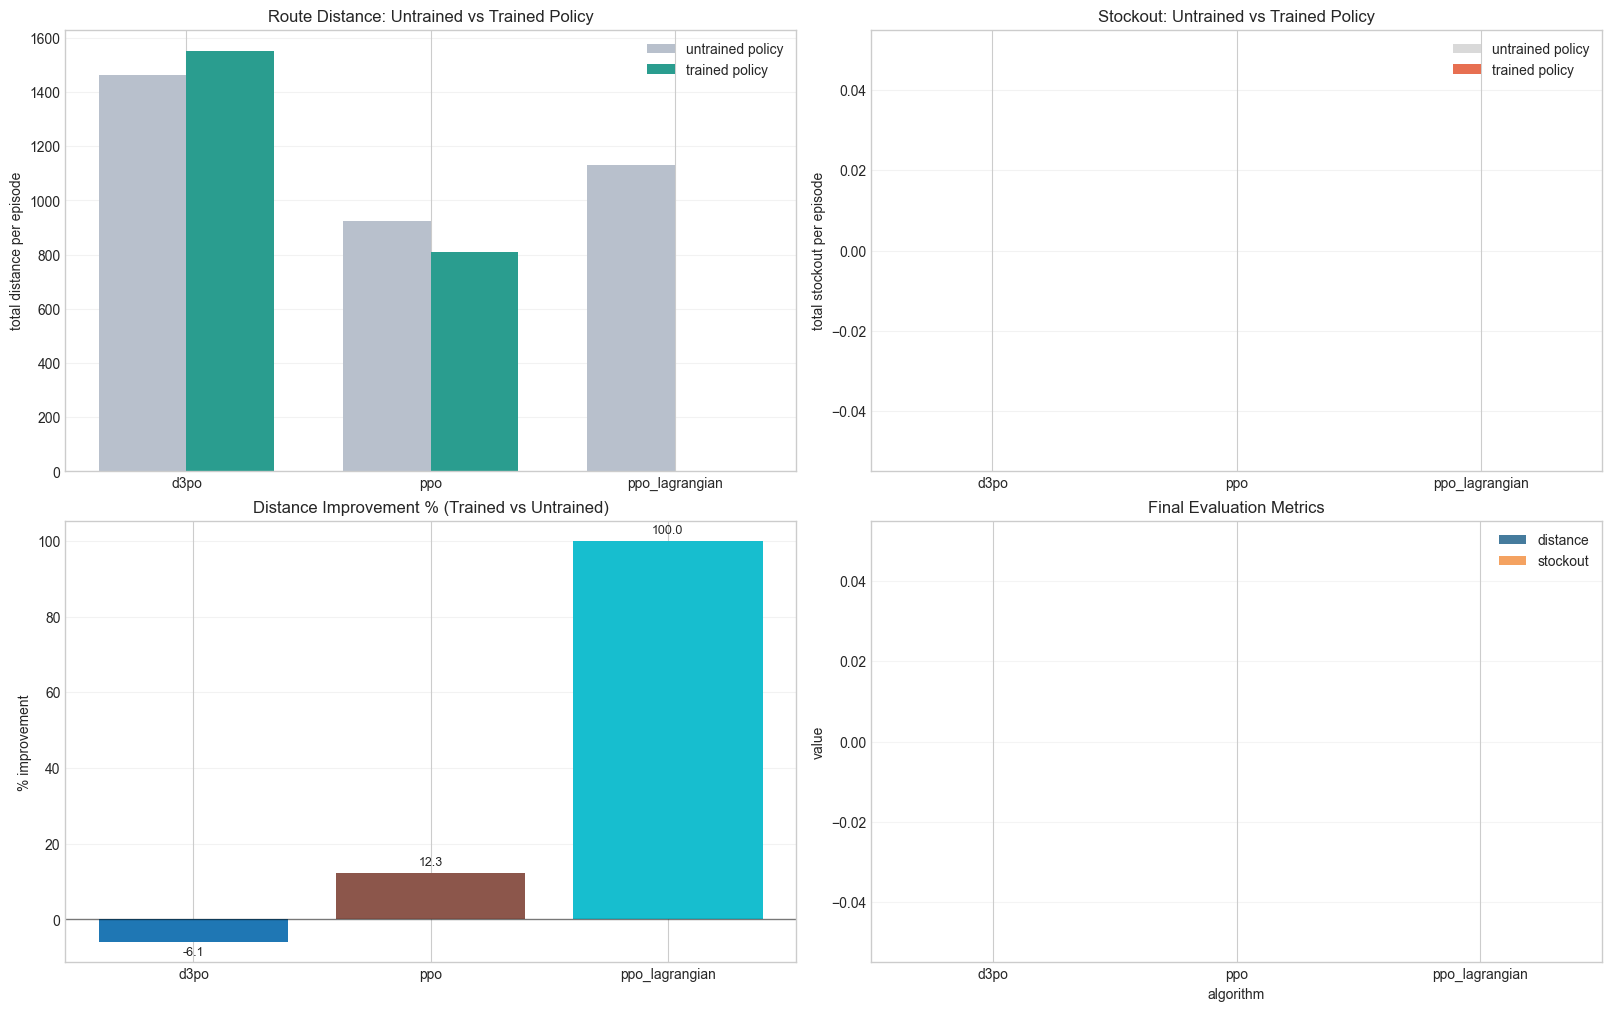

In [ ]:
plot_algorithm_summary_dashboard(results)
plt.show()
    

## 6. Training curves

`eval_distance`, `eval_stockout`, and other `eval_*` values are not computed at every training step.
They are measured every `eval_interval` iterations, so the plots show lines across evaluation checkpoints.


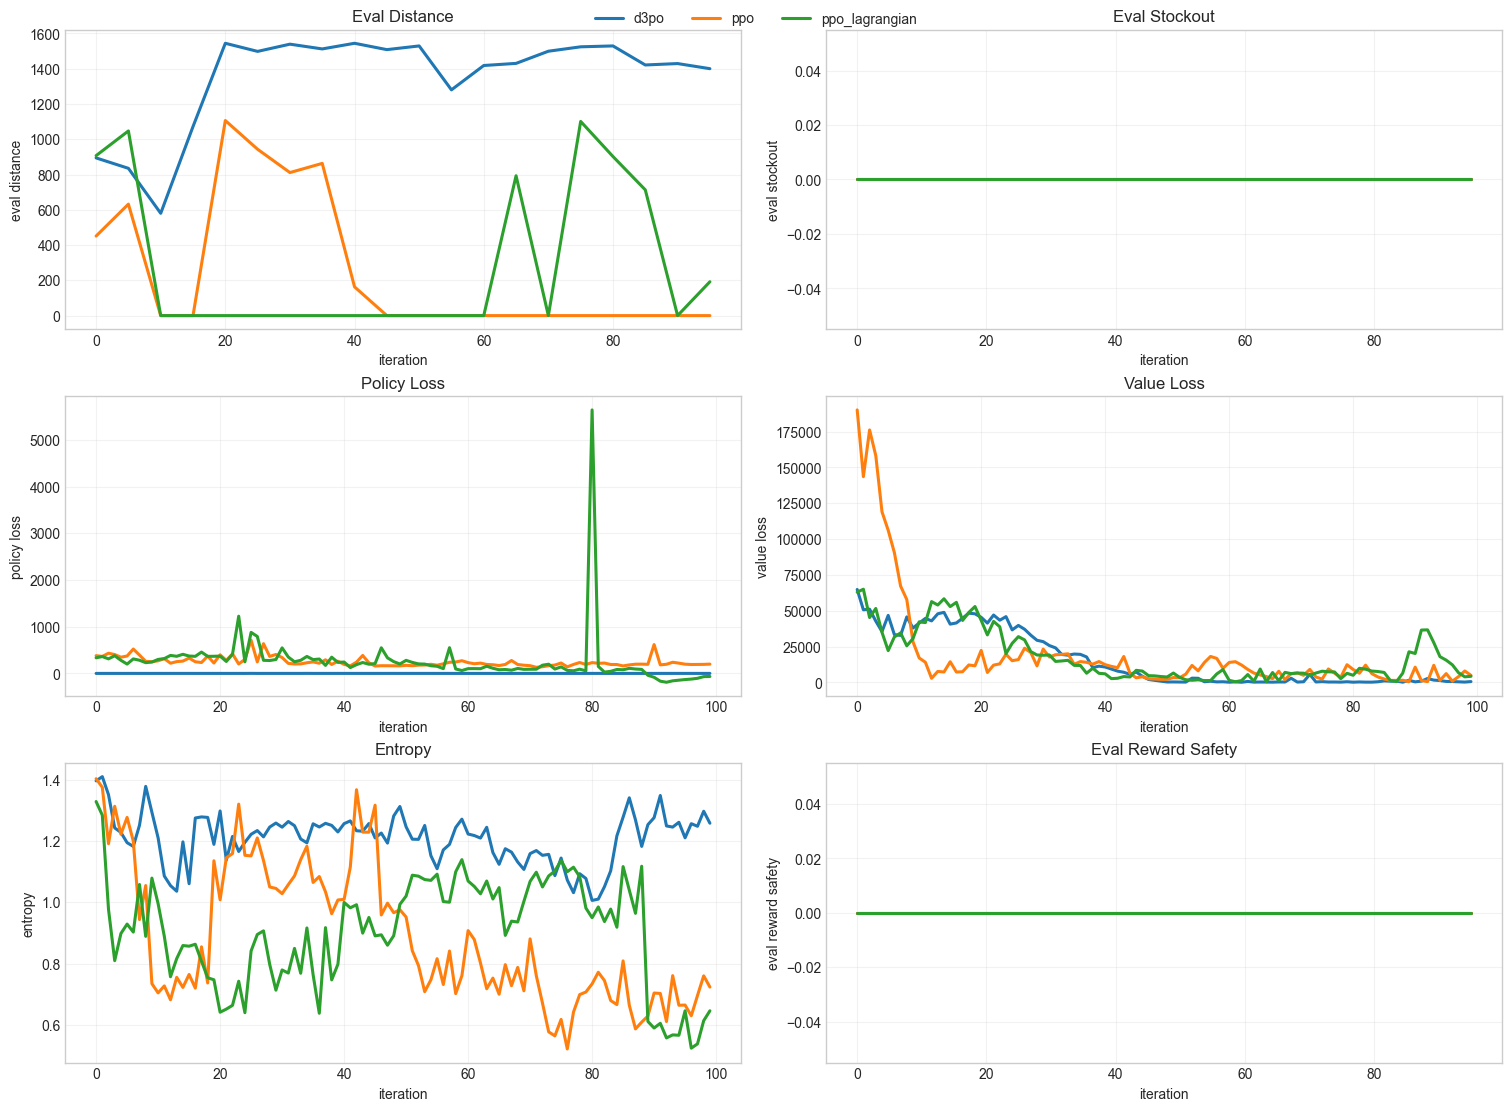

In [ ]:
plot_algorithm_comparison(
    results,
    metrics=(
        "eval_distance",
        "eval_stockout",
        "policy_loss",
        "value_loss",
        "entropy",
        "eval_reward_safety",
    ),
)
plt.show()
        


## 7. Inspect the best trained run

The best algorithm is selected by the lowest `eval_distance`, then the lowest `eval_stockout`.
Below we compare the `untrained` and `trained` rollouts for that one best algorithm.


In [ ]:
best_algorithm = summary_frame.sort_values(["eval_distance", "eval_stockout"]).index[0]
best_result = results[best_algorithm]
best_env = best_result["env"]
best_untrained_episode = best_result["before_episode"]
best_trained_episode = best_result["after_episode"]

best_kpis = pd.DataFrame(
    [
        {"policy_state": "untrained", **episode_kpis(best_env, best_untrained_episode)},
        {"policy_state": "trained", **episode_kpis(best_env, best_trained_episode)},
    ]
).set_index("policy_state")

print("Best algorithm:", best_algorithm)
display(best_kpis)
        


Best algorithm: d3po


,total_distance,total_stockout,total_delivered,unique_stations_visited,depot_returns,service_steps,mean_fill_ratio,final_fill_ratio,n_steps
policy_state,,,,,,,,,
untrained,1463.0,0.0,456.0,5.0,13.0,19.0,0.643,0.722,32.0
trained,1552.0,0.0,480.0,5.0,12.0,20.0,0.663,0.747,32.0


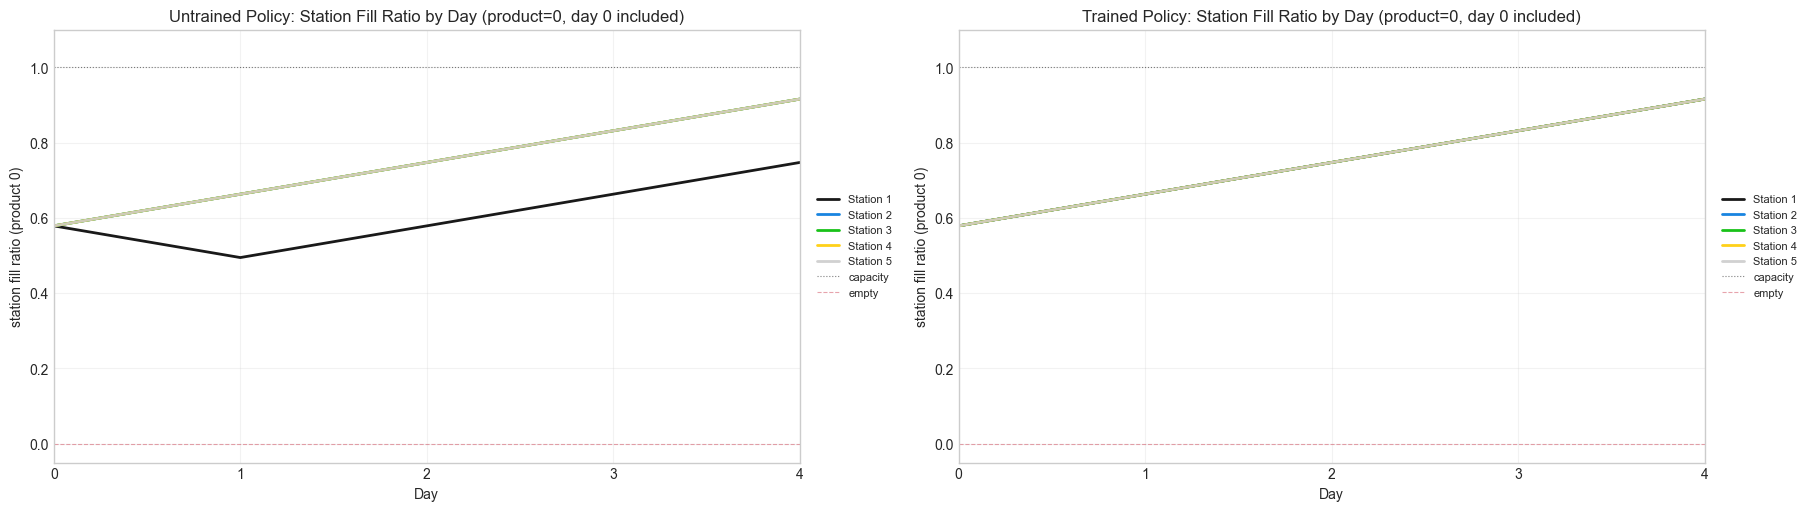

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)
plot_inventory_dynamics(
    best_env,
    best_untrained_episode,
    ax=axes[0],
    product=TRACKED_PRODUCT,
    title=f"Untrained Policy: Station Fill Ratio by Day (product={TRACKED_PRODUCT}, day 0 included)",
)
plot_inventory_dynamics(
    best_env,
    best_trained_episode,
    ax=axes[1],
    product=TRACKED_PRODUCT,
    title=f"Trained Policy: Station Fill Ratio by Day (product={TRACKED_PRODUCT}, day 0 included)",
)
plt.show()
        


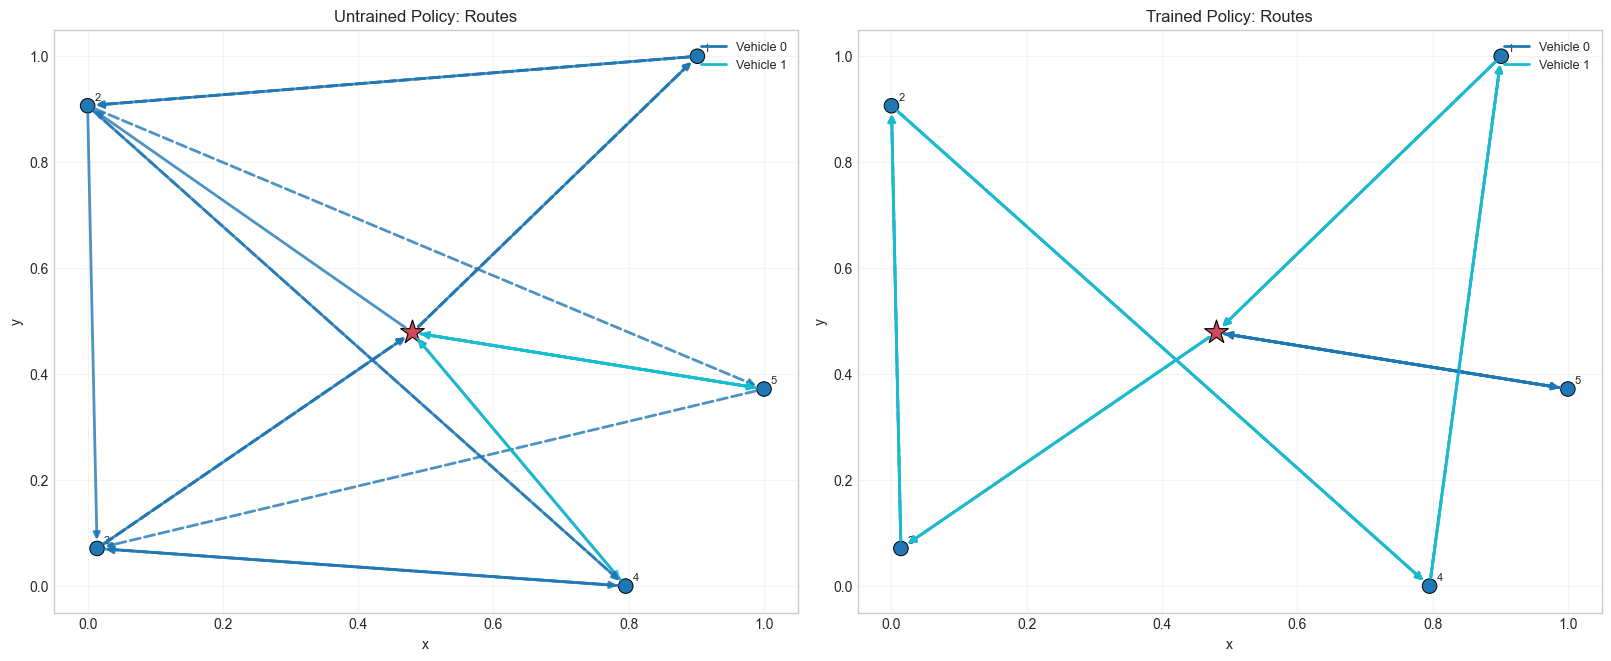

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), constrained_layout=True)
plot_route_map(best_env, best_untrained_episode, ax=axes[0])
axes[0].set_title("Untrained Policy: Routes")
plot_route_map(best_env, best_trained_episode, ax=axes[1])
axes[1].set_title("Trained Policy: Routes")
plt.show()
        


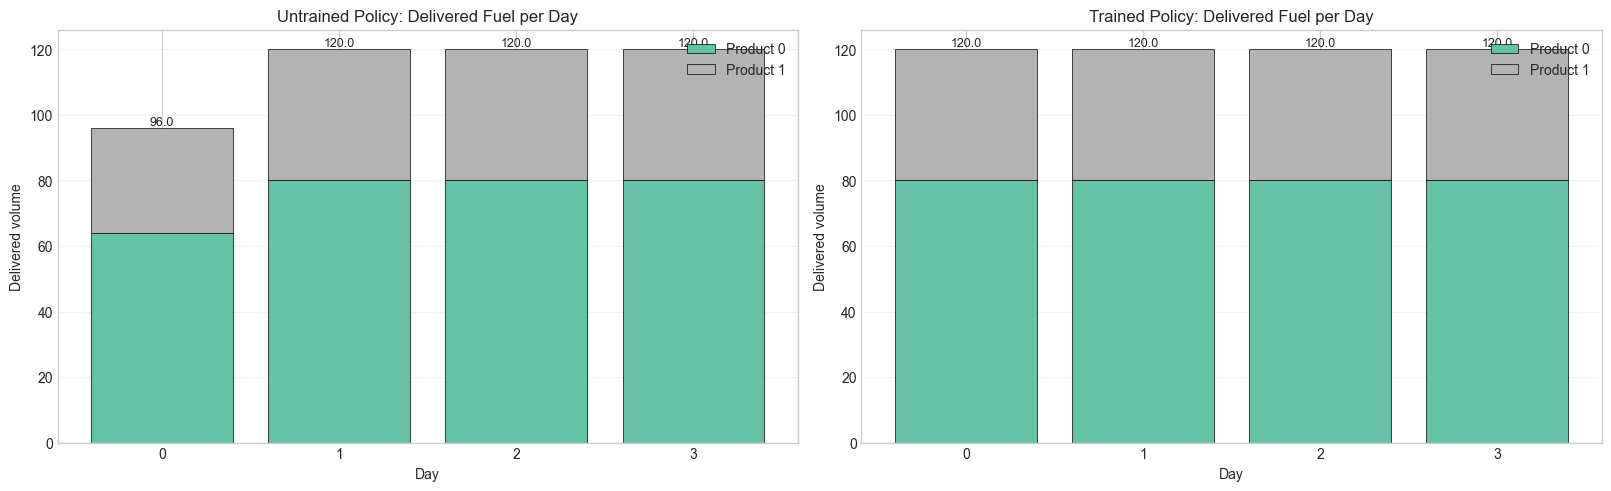

,day,step,vehicle,from_node,to_node,delivered
0,0,0,0,0,3,24.0
1,0,1,1,0,5,24.0
2,0,2,0,3,2,24.0
3,0,3,0,2,4,24.0
4,0,4,0,4,1,24.0
5,0,5,0,1,0,0.0
6,0,6,0,0,0,0.0
7,0,7,1,5,0,0.0
8,1,8,1,0,3,24.0
9,1,9,0,0,5,24.0


Total route segments in best trained rollout: 32


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8), constrained_layout=True)
plot_daily_delivered(best_env, best_untrained_episode, ax=axes[0])
axes[0].set_title("Untrained Policy: Delivered Fuel per Day")
plot_daily_delivered(best_env, best_trained_episode, ax=axes[1])
axes[1].set_title("Trained Policy: Delivered Fuel per Day")
plt.show()

trained_routes = daily_route_frame(best_trained_episode)
display(trained_routes.head(40))
print(f"Total route segments in best trained rollout: {len(trained_routes)}")
        


## 8. Compare trained RL policies with CP-SAT

Now we move to the solver comparison.
Each trained RL policy is evaluated on the same shared instance and compared against the CP-SAT baseline built from the same generator data.


In [ ]:
cpsat_results = {}
for label, result in results.items():
    cpsat_results[label] = compare_policy_to_cpsat(
        result["env"],
        result["policy"],
        cpsat_bundle=bundle,
        preferences=result.get("eval_preferences"),
        deterministic=DETERMINISTIC_EVAL,
    )

cpsat_frame = cpsat_comparison_frame(cpsat_results)
cpsat_columns = [
    "source",
    "total_travel_distance",
    "cumulative_stockout",
    "average_stock_levels_percent",
    "average_vehicle_utilization",
    "average_stops_per_trip",
    "steps",
    "total_travel_distance_gap_to_cpsat",
    "cumulative_stockout_gap_to_cpsat",
]
available_cpsat_columns = [col for col in cpsat_columns if col in cpsat_frame.columns]
display(cpsat_frame[available_cpsat_columns])
        


,source,total_travel_distance,cumulative_stockout,average_stock_levels_percent,average_vehicle_utilization,average_stops_per_trip,steps,total_travel_distance_gap_to_cpsat,cumulative_stockout_gap_to_cpsat
solver,,,,,,,,,
ppo,trained_policy,0.0,0.0,36.842,0.0,0.0,8.0,0.0,NaN
ppo_lagrangian,trained_policy,0.0,0.0,36.842,0.0,0.0,8.0,0.0,NaN
d3po,trained_policy,0.0,0.0,36.842,0.0,0.0,8.0,0.0,NaN
cpsat,cp_sat_solver,0.0,NaN,36.842,0.0,0.0,NaN,0.0,0.0


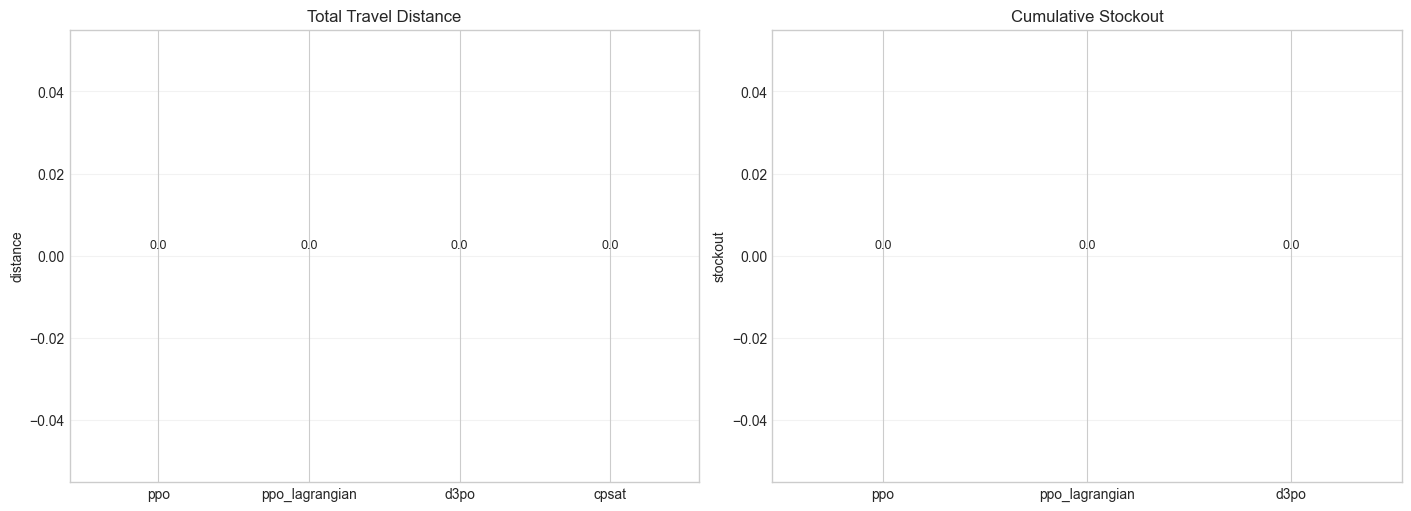

In [ ]:
plot_cpsat_comparison(cpsat_frame)
plt.show()
        


## 9. Scale up to fuller experiments

For longer runs, switch to `experiment=full`.
The table below shows the active presets, and the CLI commands can be used outside the notebook.


In [ ]:
benchmark_cfg = load_config([f"env={ENV_NAME}", "experiment=benchmark"])
full_cfg = load_config([f"env={ENV_NAME}", "experiment=full"])

preset_frame = pd.DataFrame(
    [
        {
            "preset": "benchmark",
            "total_iterations": int(benchmark_cfg.experiment.total_iterations),
            "eval_interval": int(benchmark_cfg.experiment.eval_interval),
            "eval_episodes": int(benchmark_cfg.experiment.eval_episodes),
            "comparison_eval_episodes": int(benchmark_cfg.experiment.comparison_eval_episodes),
        },
        {
            "preset": "full",
            "total_iterations": int(full_cfg.experiment.total_iterations),
            "eval_interval": int(full_cfg.experiment.eval_interval),
            "eval_episodes": int(full_cfg.experiment.eval_episodes),
            "comparison_eval_episodes": int(full_cfg.experiment.comparison_eval_episodes),
        },
    ]
).set_index("preset")

display(preset_frame)

print("CLI examples:")
print(r"python scripts/train.py env=small experiment=benchmark algo=ppo")
print(r"python scripts/train.py env=small experiment=full algo=d3po")
print(r"python scripts/train.py env=medium experiment=full algo=ppo_lagrangian")

,total_iterations,eval_interval,eval_episodes,comparison_eval_episodes
preset,,,,
benchmark,100,5,6,8
full,400,10,8,12


CLI examples:
python scripts/train.py env=small experiment=benchmark algo=ppo
python scripts/train.py env=small experiment=full algo=d3po
python scripts/train.py env=medium experiment=full algo=ppo_lagrangian


## Notes

- `day 0` in the inventory-dynamics plot is the initial station state before any action is taken.
- `eval_*` curves are based on checkpoint evaluations, so the line connects measured values between evaluation iterations.
- The RL vs `CP-SAT` benchmark already uses the same shared instance, but the formulations are still not perfectly identical.
- [notebooks/01_cpsat_comparison.ipynb](/d:/PythonProjects/PSRP_D3PO/notebooks/01_cpsat_comparison.ipynb) is kept only as a small legacy redirect.
